<a href="https://colab.research.google.com/github/JCRMurillo/Telecom_X_JCRM/blob/main/TelecomX_JCRM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_json("TelecomX_Data.json")

In [3]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
datos = pd.concat(
    [
        df[["customerID", "Churn"]],
        pd.json_normalize(df["customer"]).add_prefix(""),
        pd.json_normalize(df["phone"]),
        pd.json_normalize(df["internet"]),
        pd.json_normalize(df["account"])

    ],
    axis=1
)

In [5]:
datos.tail()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [7]:
datos["Charges.Total"] = datos["Charges.Total"].replace({"": None, " ": None})
datos["Charges.Total"] = datos["Charges.Total"].astype(float)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [8]:
datos = datos.round(2)

In [9]:
datos["Churn"] = datos["Churn"].replace({"": None, " ": None})
pd.unique(datos["Churn"])


array(['No', 'Yes', None], dtype=object)

In [10]:
datos["Cuentas_Diarias"] = (datos["Charges.Monthly"] / 30).round(2)
datos[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [11]:
datos[["tenure", "Charges.Monthly", "Charges.Total", "Cuentas_Diarias"]].describe().round(2)


,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.00,7267.00,7256.00,7267.00
mean,32.35,64.72,2280.63,2.16
std,24.57,30.13,2268.63,1.00
min,0.00,18.25,18.80,0.61
25%,9.00,35.42,400.22,1.18
50%,29.00,70.30,1391.00,2.34
75%,55.00,89.88,3785.30,3.00
max,72.00,118.75,8684.80,3.96


In [12]:
datos["Contract"].value_counts(normalize=True)


,proportion
Contract,
Month-to-month,0.551122
Two year,0.239851
One year,0.209027


In [13]:
(datos["Churn"] == "Yes").mean()


np.float64(0.257190037154259)

In [14]:
pd.crosstab(datos["Contract"], datos["Churn"], normalize="index")


Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [15]:
pd.crosstab(datos["PaymentMethod"], datos["Churn"], normalize="index")


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


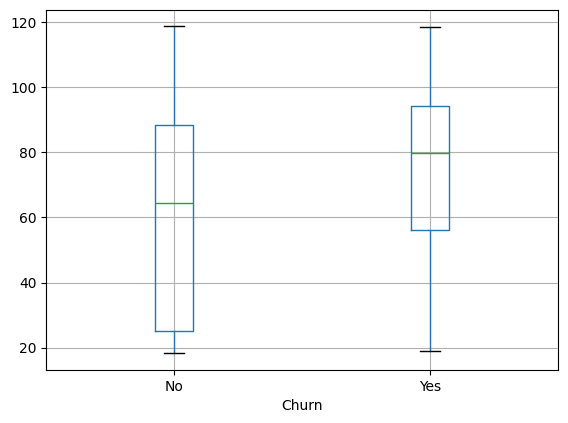

In [16]:
import matplotlib.pyplot as plt

datos.boxplot(column="Charges.Monthly", by="Churn")
plt.title("")
plt.suptitle("")
plt.show()

In [17]:
def churn_por_categoria(df, col):
    tabla = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    tabla = tabla.rename(columns={"No": "No dejan la compania", "Yes": "Dejan la compania"})
    return tabla.sort_values(by="Dejan la compania", ascending=False)

In [18]:
churn_por_categoria(datos, "gender")


Churn,No dejan la compania,Dejan la compania
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [19]:
churn_por_categoria(datos, "Contract")


Churn,No dejan la compania,Dejan la compania
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [20]:
churn_por_categoria(datos, "PaymentMethod")


Churn,No dejan la compania,Dejan la compania
PaymentMethod,,
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101


In [21]:
churn_por_categoria(datos, "InternetService")


Churn,No dejan la compania,Dejan la compania
InternetService,,
Fiber optic,58.107235,41.892765
DSL,81.040892,18.959108
No,92.595020,7.404980


In [22]:
churn_por_categoria(datos, "Partner")
churn_por_categoria(datos, "Dependents")


Churn,No dejan la compania,Dejan la compania
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


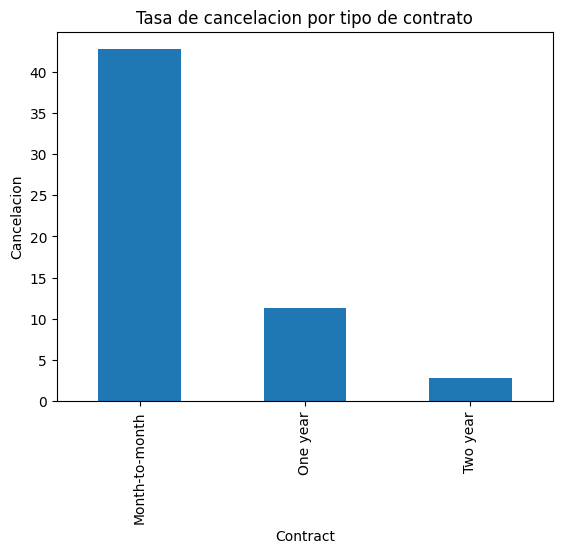

In [26]:
import matplotlib.pyplot as plt

churn_contract = churn_por_categoria(datos, "Contract")

churn_contract["Dejan la compania"].plot(kind="bar")
plt.ylabel("Cancelacion")
plt.title("Tasa de cancelacion por tipo de contrato")
plt.show()


In [24]:
datos.groupby("Churn")[["tenure", "Charges.Monthly", "Charges.Total", "Cuentas_Diarias"]].agg(
    ["mean", "median", "std", "min", "max"]
)

tenure                           Charges.Monthly                     \
            mean median        std min max            mean  median        std   
Churn                                                                           
No     37.569965   38.0  24.113777   0  72       61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123   1  72       74.441332  79.650  24.666053   

                     Charges.Total                                        \
         min     max          mean   median          std    min      max   
Churn                                                                      
No     18.25  118.75   2555.344141  1683.60  2329.456984  18.80  8672.45   
Yes    18.85  118.35   1531.796094   703.55  1890.822994  18.85  8684.80   

      Cuentas_Diarias                               
                 mean median       std   min   max  
Churn                                               
No            2.04208   2.15  1.036492  0.61  3.96  
Yes           2.48145   2.66  0.822287  0.63  3.94

In [29]:
datos.groupby("Churn")[["tenure", "Charges.Monthly", "Cuentas_Diarias"]].mean()

,tenure,Charges.Monthly,Cuentas_Diarias
Churn,,,
No,37.569965,61.265124,2.04208
Yes,17.979133,74.441332,2.48145


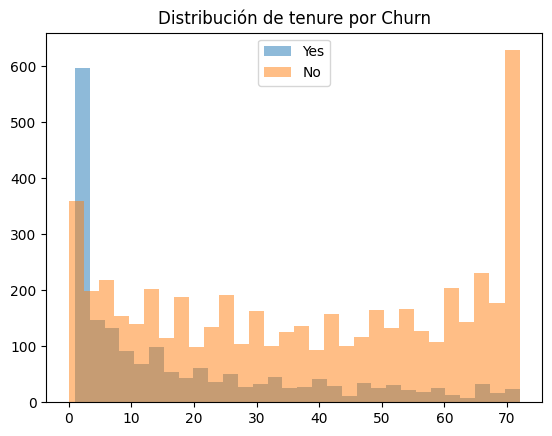

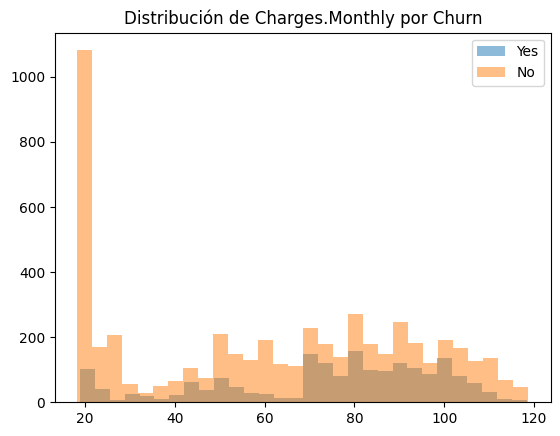

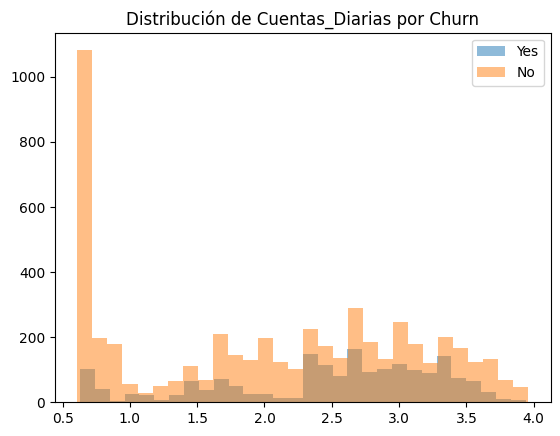

In [27]:
for col in ["tenure", "Charges.Monthly", "Cuentas_Diarias"]:
    plt.figure()
    for estado in ["Yes", "No"]:
        subset = datos[datos["Churn"] == estado]
        plt.hist(subset[col], bins=30, alpha=0.5, label=estado)
    plt.title(f"Distribución de {col} por Churn")
    plt.legend()
    plt.show()

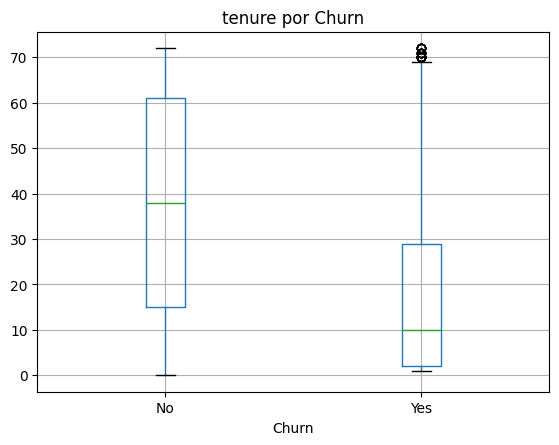

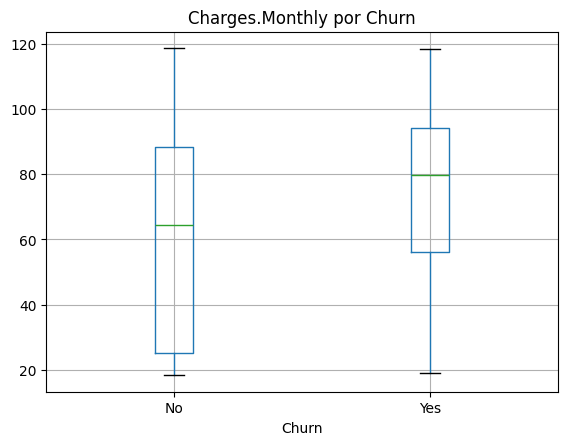

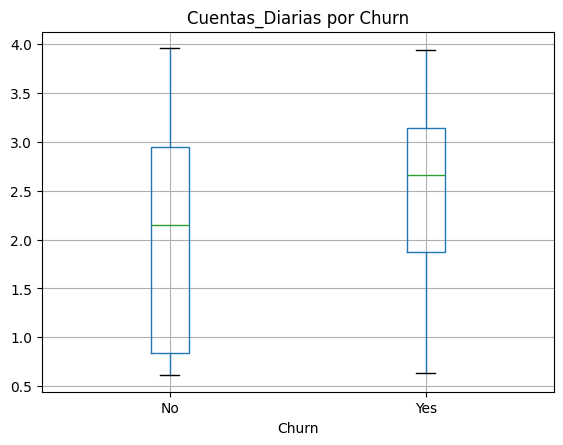

In [28]:
for col in ["tenure", "Charges.Monthly", "Cuentas_Diarias"]:
    datos.boxplot(column=col, by="Churn")
    plt.title(f"{col} por Churn")
    plt.suptitle("")
    plt.show()

#*Informe Final*

El objetivo de este análisis es determinar los diferentes factores que llevan a los clientes de la empresa TelecomX a cancelar sus servicios. Para efectos prácticos, al momento de leer la base de datos se denominó esta variable como “Churn”. Para lograr este objetivo se realizó el tratamiento de los datos, un análisis y la graficación de los resultados obtenidos.

El primer paso a realizar fue la importación y tratamiento de la base de datos, la cual se encontraba en formato JSON. Se creó un DataFrame haciendo uso de la librería pandas y, a continuación, se obtuvo la información que se encontraba anidada para la construcción del DataFrame a utilizar durante el análisis. Para algunas columnas como “tenure”, “Charges.Monthly” y “Charges.Total” se convirtieron sus valores a formato numérico. También se removieron valores que entorpecieran los análisis y se creó finalmente una nueva columna llamada “Cuentas_Diarias”, la cual calcula el gasto diario de los clientes haciendo una aproximación de 30 días por mes. Finalmente, se redondearon los valores numéricos para facilitar su interpretación al momento de realizar el análisis.

En segundo lugar, se realizó un análisis descriptivo de las variables numéricas más importantes, calculando medidas estándar como la media, la mediana y la desviación estándar. De igual manera, teniendo como variable dependiente el Churn, se analizó la distribución de este según variables categóricas como el tipo de contrato, el método de pago, el género y los servicios contratados. Finalmente, se generaron gráficas que apoyan los análisis realizados anteriormente.

Este análisis permitió identificar patrones en el comportamiento de los clientes que cancelan su servicio. De manera general, los clientes de esta compañía que cancelan sus servicios tienen un tiempo muy corto en la empresa, por lo que la cancelación ocurre en los primeros meses de contrato. Se observó que existe una relación directa entre el gasto de los clientes y la decisión de cancelar el servicio; a mayor gasto, mayor es la probabilidad de que el cliente cancele. De igual manera, los contratos que se renuevan mensualmente tienden a tener una mayor tasa de cancelación que los contratos de larga duración. El método de pago también parece ser un factor que influye en la decisión de cancelación, especialmente el pago electrónico (“Electronic check”). Finalmente, los clientes que tienen dependientes o pareja presentan una menor tendencia a cancelar su servicio.

A partir de estos resultados, se pueden proponer varias recomendaciones para reducir la evasión de clientes en la empresa. En primer lugar, se sugiere incentivar a los clientes a adquirir contratos de mayor duración mediante beneficios o descuentos, con el fin de aumentar su permanencia en la compañía. También sería conveniente revisar la estructura de precios para los clientes con mayores gastos mensuales, buscando mejorar la percepción de valor del servicio. Dado que la cancelación ocurre principalmente en los primeros meses, se recomienda implementar estrategias de fidelización temprana dirigidas a nuevos clientes. Asimismo, se podría promover el uso de métodos de pago automáticos como tarjeta de crédito o transferencia bancaria, en lugar del “Electronic check”. Finalmente, la empresa podría identificar a los clientes con mayor riesgo de cancelación (alto gasto mensual y bajo tiempo de permanencia) para aplicar acciones de retención más específicas y efectivas.
